In [2]:
import cv2 as cv
import os
import tensorflow as tf
import matplotlib.pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np

In [3]:
img = cv.imread(r"C:\Users\Shishupal Kumar\OneDrive\Desktop\python-project\12_face_prediction_in_attendance\datasets\output_datasets\train\shishupal\image2_aug_0.jpg")
# opencv BGR channel format and plt reads as RGB channel format

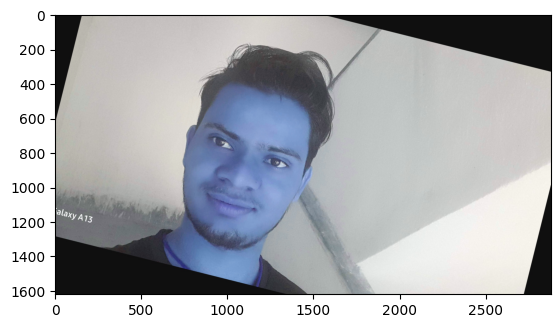

In [4]:
plt.imshow(img) # RGB format

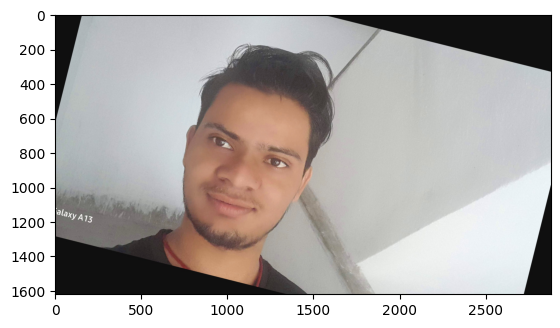

In [5]:
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)  # 

In [6]:
from mtcnn.mtcnn import MTCNN

detector = MTCNN()
results = detector.detect_faces(img)

In [7]:
results

[{'box': [784, 432, 653, 875],
  'confidence': np.float64(0.9988235831260681),
  'keypoints': {'nose': [np.int64(1065), np.int64(972)],
   'mouth_right': [np.int64(1169), np.int64(1129)],
   'right_eye': [np.int64(1279), np.int64(855)],
   'left_eye': [np.int64(971), np.int64(746)],
   'mouth_left': [np.int64(886), np.int64(1033)]}}]

In [8]:
x,y,w,h = results[0]['box']

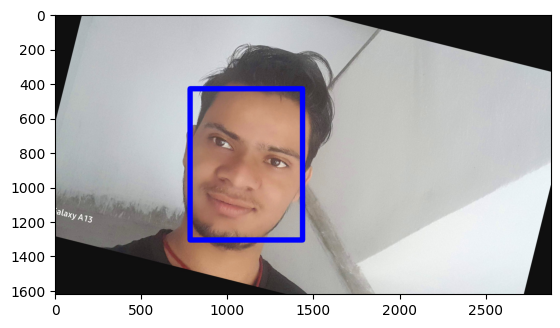

In [9]:
img = cv.rectangle(img, (x,y) , (x+w , y+h) , (0,0,255),30)
plt.imshow(img)

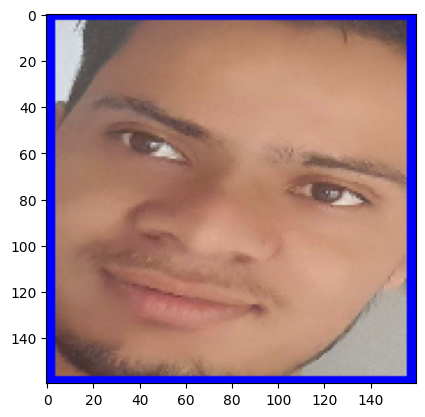

In [10]:
my_face = img[y:y+h , x:x+w]
#Facenet takes as input 160*160
my_face = cv.resize(my_face , (160,160))
plt.imshow(my_face) 

In [11]:
my_face

array([[[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       ...,

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]]

# Automate the preprocessing

In [12]:
import numpy as np

In [13]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN


class FACELOADING:
    def __init__(self, directory):
        self.directory = directory
        self.target_size = (160, 160)
        self.X = []
        self.Y = []
        self.detector = MTCNN()

    # -------------------------------------------------
    # Extract a single face from image
    # -------------------------------------------------
    def extract_face(self, filename):
        img = cv.imread(filename)

        if img is None:
            return None

        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        faces = self.detector.detect_faces(img)

        if len(faces) == 0:
            return None

        x, y, w, h = faces[0]['box']
        x, y = abs(x), abs(y)

        face = img[y:y+h, x:x+w]
        face_arr = cv.resize(face, self.target_size)

        return face_arr

    # -------------------------------------------------
    # Load all faces from one class folder
    # -------------------------------------------------
    def load_faces(self, dir_path):
        FACES = []

        for img_name in os.listdir(dir_path):
            img_path = os.path.join(dir_path, img_name)

            try:
                face = self.extract_face(img_path)
                if face is not None:
                    FACES.append(face)
            except:
                pass

        return FACES

    # -------------------------------------------------
    # Load all classes (persons)
    # -------------------------------------------------
    def load_classes(self):
        for sub_dir in os.listdir(self.directory):
            class_path = os.path.join(self.directory, sub_dir)

            if not os.path.isdir(class_path):
                continue

            FACES = self.load_faces(class_path)
            labels = [sub_dir] * len(FACES)

            print(f"Loaded {len(FACES)} images for class: {sub_dir}")

            self.X.extend(FACES)
            self.Y.extend(labels)

        return np.asarray(self.X), np.asarray(self.Y)

    # -------------------------------------------------
    # Plot loaded images
    # -------------------------------------------------
    def plot_images(self, max_images=12):
        plt.figure(figsize=(12, 10))

        total = min(len(self.X), max_images)
        cols = 4
        rows = total // cols + 1

        for i in range(total):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(self.X[i])
            plt.title(self.Y[i])
            plt.axis("off")

        plt.show()


In [16]:
faceloading = FACELOADING(r"C:\Users\Shishupal Kumar\OneDrive\Desktop\python-project\12_face_prediction_in_attendance\datasets\output_datasets\train")
X, Y = faceloading.load_classes()

Loaded 36 images for class: alia bhatt
Loaded 52 images for class: allen newell
Loaded 39 images for class: Avi
Loaded 83 images for class: geoffrey hinton
Loaded 114 images for class: Hritik roshan
Loaded 42 images for class: john abraham
Loaded 54 images for class: paul werbos
Loaded 62 images for class: Raja
Loaded 27 images for class: shishupal
Loaded 48 images for class: Tiger shroff


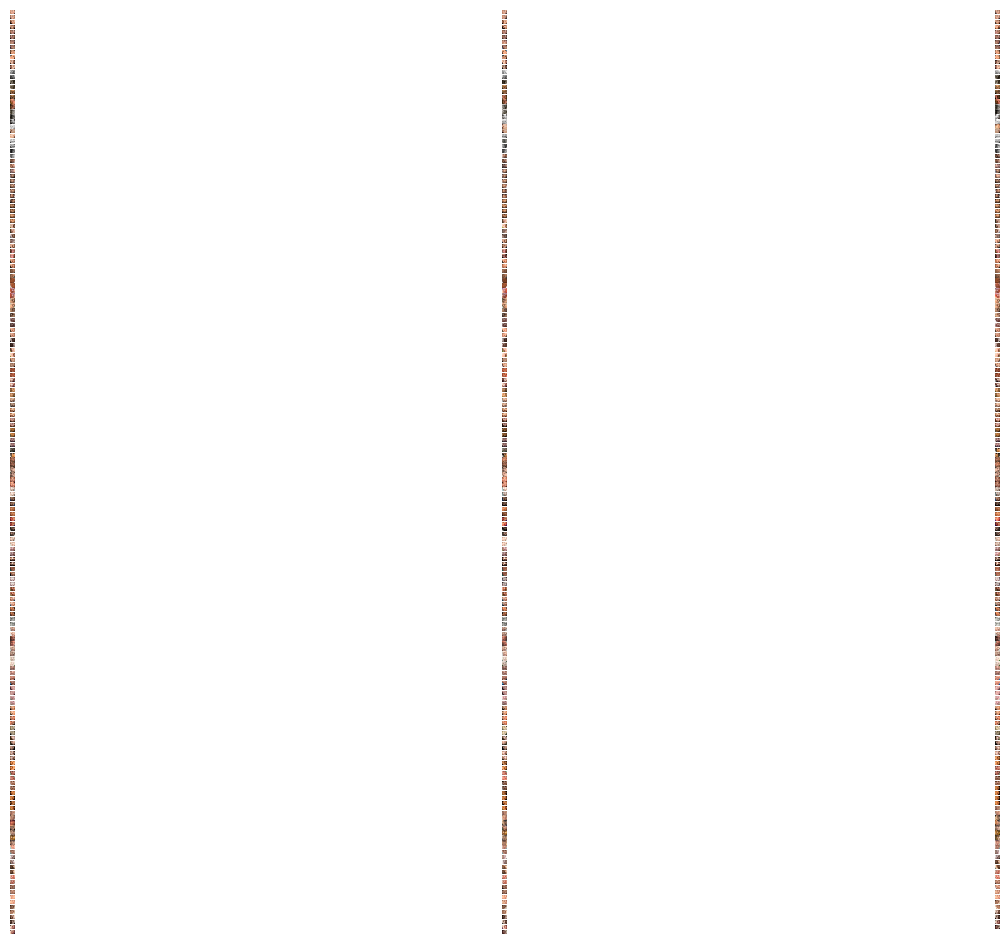

In [17]:
plt.figure(figsize=(18,12))
for num,image in enumerate(X):
    ncols = 3
    nrows = len(Y)//ncols + 1
    plt.subplot(nrows,ncols,num+1)
    plt.imshow(image)
    plt.axis('off')

# FaceNet part

In [18]:
pip install keras-facenet


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from keras_facenet import FaceNet
embedder = FaceNet()

def get_embedding(face_img):
    face_img = face_img.astype('float32') # 3D(160x160x3)
    face_img = np.expand_dims(face_img, axis=0) 
    # 4D (Nonex160x160x3)
    yhat= embedder.embeddings(face_img)
    return yhat[0] # 512D image (1x1x512)

In [20]:
EMBEDDED_X = []

for img in X:
    EMBEDDED_X.append(get_embedding(img))

EMBEDDED_X = np.asarray(EMBEDDED_X)
EMBEDDED_X

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117

array([[-0.06892018,  0.03007972, -0.04929264, ..., -0.04431526,
        -0.01409397,  0.02904482],
       [-0.06878206,  0.01184442, -0.08513024, ..., -0.0617713 ,
         0.00123749,  0.02313733],
       [-0.06381417,  0.00700192, -0.08555134, ..., -0.02752019,
        -0.01559743,  0.03433271],
       ...,
       [ 0.0521107 ,  0.04104362,  0.01801147, ...,  0.00964532,
        -0.01901259,  0.02067512],
       [ 0.07602821, -0.01203978, -0.005012  , ...,  0.01342226,
        -0.05437439, -0.01222694],
       [ 0.04199515,  0.03212353,  0.00639505, ..., -0.01433924,
        -0.04370743,  0.05507306]], shape=(557, 512), dtype=float32)

In [21]:
np.savez_compressed('faces_embeddings.npz', EMBEDDED_X, Y)

# SVM model

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)

In [24]:
import pickle
with open("label_encoder.pkl", "wb") as f:

    pickle.dump(encoder, f)

In [25]:
print(encoder.classes_)

['Avi' 'Hritik roshan' 'Raja' 'Tiger shroff' 'alia bhatt' 'allen newell'
 'geoffrey hinton' 'john abraham' 'paul werbos' 'shishupal']


Text(0, 0.5, '4')

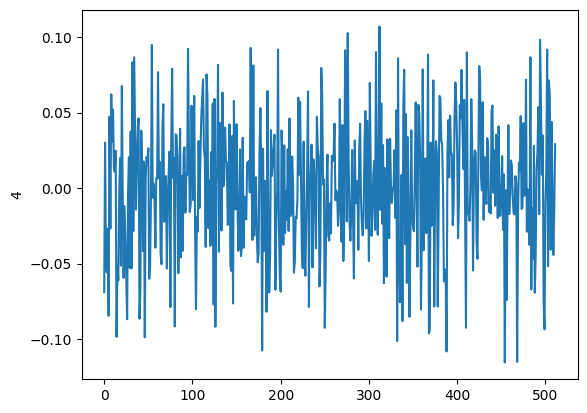

In [26]:
plt.plot(EMBEDDED_X[0]) 
plt.ylabel(Y[0])

In [27]:
Y

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(EMBEDDED_X, Y, shuffle=True, random_state=17)

In [29]:
from sklearn.svm import SVC
model = SVC(kernel='linear', probability=True)
model.fit(X_train, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
ypreds_train = model.predict(X_train)
ypreds_test = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_train, ypreds_train)

0.9808153477218226

In [32]:
accuracy_score(Y_test,ypreds_test)

0.9714285714285714

In [33]:
t_im = cv.imread(r"C:\Users\Shishupal Kumar\OneDrive\Desktop\python-project\12_face_prediction_in_attendance\datasets\output_datasets\train\shishupal\image2_aug_0.jpg")
t_im = cv.cvtColor(t_im, cv.COLOR_BGR2RGB)
x,y,w,h = detector.detect_faces(t_im)[0]['box']

In [34]:
t_im = t_im[y:y+h, x:x+w]
t_im = cv.resize(t_im, (160,160))
test_im = get_embedding(t_im)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [35]:
test_im = [test_im]
ypreds = model.predict(test_im)

In [36]:
ypreds

array([9])

In [37]:
encoder.inverse_transform(ypreds)

array(['shishupal'], dtype='<U15')

In [38]:
import pickle
#save the model
with open('svm_model_160x160.pkl','wb') as f:
    pickle.dump(model,f)